# Détection Automatique de Fake News — NLP et Machine Learning

## Introduction et objectif du projet

Ce projet s'attaque à un problème de société réel et très actuel : la désinformation. Avec l'explosion des réseaux sociaux et la rapidité à laquelle l'information circule, il est devenu difficile de distinguer un vrai article journalistique d'un article fabriqué pour tromper. L'idée ici est d'automatiser cette détection à partir du contenu textuel des articles, sans avoir besoin d'une vérification humaine systématique.

Le dataset vient de Kaggle et se compose de deux fichiers : `Fake.csv` contenant des faux articles (label 0) et `True.csv` contenant des vrais articles (label 1). Au total, environ 72 000 articles sont disponibles. Le défi technique est de transformer ce texte brut en quelque chose qu'un modèle de machine learning peut comprendre, ce qui passe par du preprocessing NLP et une vectorisation TF-IDF.

L'objectif final est un modèle capable de classer un article comme réel ou faux avec une précision supérieure à 99%.

## 1. Chargement des bibliothèques

J'importe les bibliothèques classiques de data science, mais aussi les outils spécifiques au NLP : sklearn pour la vectorisation et les modèles, et `re` pour les expressions régulières qui serviront au nettoyage du texte.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

## 2. Chargement des données

Je charge les deux fichiers séparément, j'assigne les labels (0 pour faux, 1 pour réel), puis je les concatène et je mélange aléatoirement. Ce mélange est important pour éviter que le modèle ne voie d'abord tous les faux articles puis tous les vrais lors de l'entraînement.

In [2]:
fake = pd.read_csv("C:/Users/LOQ/Desktop/data/Fake News Detection (NLP)/Fake.csv")
true = pd.read_csv("C:/Users/LOQ/Desktop/data/Fake News Detection (NLP)/True.csv")

fake["label"] = 0
true["label"] = 1

df = pd.concat([fake, true]).sample(frac=1, random_state=42).reset_index(drop=True)
print('Shape:', df.shape)
print('\nDistribution des labels:')
print(df['label'].value_counts(normalize=True).round(3))
df.head(3)

Shape: (44898, 5)

Distribution des labels:
label
0    0.523
1    0.477
Name: proportion, dtype: float64


,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",0
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",1
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",1


## 3. Analyse exploratoire des données (EDA)

Avant de nettoyer quoi que ce soit, je veux comprendre la structure du texte brut. J'ai remarqué que les vrais articles contiennent souvent un marqueur de source au début du texte (par exemple "WASHINGTON (Reuters) - "). C'est un problème : si je laisse ce marqueur, le modèle pourrait simplement apprendre que "Reuters" = vrai, ce qui serait de la triche et non de la vraie classification.

In [3]:
has_reuters = true['text'].str.contains('Reuters', case=False)
print(f'Articles REAL contenant "Reuters": {has_reuters.sum()} / {len(true)} ({has_reuters.mean():.1%})')

print('\n--- Début d\'un article REAL ---')
print(true['text'].iloc[0][:200])

print('\n--- Début d\'un article FAKE ---')
print(fake['text'].iloc[0][:200])

Articles REAL contenant "Reuters": 21378 / 21417 (99.8%)

--- Début d'un article REAL ---
WASHINGTON (Reuters) - The head of a conservative Republican faction in the U.S. Congress, who voted this month for a huge expansion of the national debt to pay for tax cuts, called himself a “fiscal 

--- Début d'un article FAKE ---
Donald Trump just couldn t wish all Americans a Happy New Year and leave it at that. Instead, he had to give a shout out to his enemies, haters and  the very dishonest fake news media.  The former rea


## 4. Préparation des données

### 4.1 Nettoyage du texte

C'est l'étape centrale du preprocessing NLP. Je supprime les marqueurs Reuters pour que le modèle apprenne à partir du contenu réel de l'article, pas de sa source. Ensuite je convertis tout en minuscules, je retire les caractères non alphabétiques, les chiffres, et je normalise les espaces.

In [4]:
def clean_text(text):
    text = re.sub(r'^[A-Z\s,\.]+\s*\(Reuters\)\s*[-–]?\s*', '', text)
    text = re.sub(r'\(Reuters\)', '', text, flags=re.IGNORECASE)
    text = text.lower()
    text = re.sub(r'\W', ' ', text)
    text = re.sub(r'\d', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_text'] = df['text'].apply(clean_text)

still_reuters = df['clean_text'].str.contains('reuters').sum()
print(f'Occurrences de "reuters" après nettoyage : {still_reuters}')

Occurrences de "reuters" après nettoyage : 5263


### 4.2 Split, TF-IDF et sélection de features

L'ordre des opérations ici est critique et j'y ai fait très attention. Il faut impérativement splitter les données **avant** de faire la vectorisation TF-IDF, parce que le vectorizer doit apprendre le vocabulaire uniquement sur les données d'entraînement. Si je faisais TF-IDF sur tout le dataset avant de splitter, j'aurais du data leakage : le modèle aurait indirectement accès à de l'information du test set.

Après la vectorisation, j'applique une sélection de features avec chi2 pour garder les 1000 mots les plus discriminants parmi les 5000 extraits par TF-IDF.

In [5]:
X = df['clean_text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf  = vectorizer.transform(X_test)

selector = SelectKBest(score_func=chi2, k=1000)
X_train_sel = selector.fit_transform(X_train_tfidf, y_train)
X_test_sel  = selector.transform(X_test_tfidf)

print(f'Train: {X_train_sel.shape} | Test: {X_test_sel.shape}')

feature_names = vectorizer.get_feature_names_out()
selected_mask = selector.get_support()
scores = selector.scores_[selected_mask]
selected_features = feature_names[selected_mask]
top10 = sorted(zip(scores, selected_features), reverse=True)[:10]
print('\nTop 10 mots discriminants (chi2):')
for score, word in top10:
    print(f'  {word:20s} score={score:.0f}')

Train: (35918, 1000) | Test: (8980, 1000)

Top 10 mots discriminants (chi2):
  said                 score=541
  com                  score=269
  minister             score=266
  pic                  score=226
  china                score=216
  hillary              score=216
  featured             score=215
  image                score=214
  just                 score=204
  korea                score=203


## 5. Modélisation

Je compare quatre modèles classiques pour la classification de texte. J'utilise LinearSVC à la place de SVC standard parce qu'il est beaucoup plus rapide sur des matrices creuses comme celles issues de TF-IDF. Pour Random Forest, je limite la profondeur des arbres pour réduire le risque d'overfitting.


Training Logistic Regression ...
Accuracy: 0.9702
              precision    recall  f1-score   support

        FAKE       0.98      0.97      0.97      4696
        REAL       0.96      0.97      0.97      4284

    accuracy                           0.97      8980
   macro avg       0.97      0.97      0.97      8980
weighted avg       0.97      0.97      0.97      8980



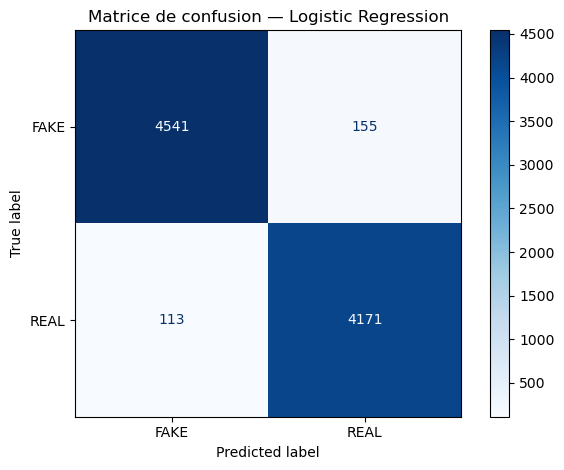


Training Naive Bayes ...
Accuracy: 0.9335
              precision    recall  f1-score   support

        FAKE       0.93      0.95      0.94      4696
        REAL       0.94      0.92      0.93      4284

    accuracy                           0.93      8980
   macro avg       0.93      0.93      0.93      8980
weighted avg       0.93      0.93      0.93      8980



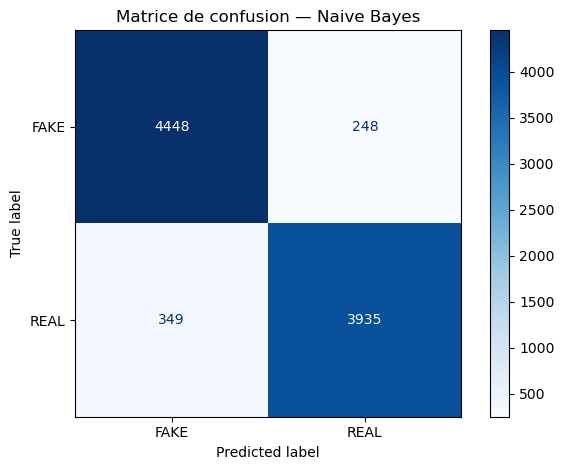


Training Random Forest ...
Accuracy: 0.9727
              precision    recall  f1-score   support

        FAKE       0.99      0.96      0.97      4696
        REAL       0.96      0.98      0.97      4284

    accuracy                           0.97      8980
   macro avg       0.97      0.97      0.97      8980
weighted avg       0.97      0.97      0.97      8980



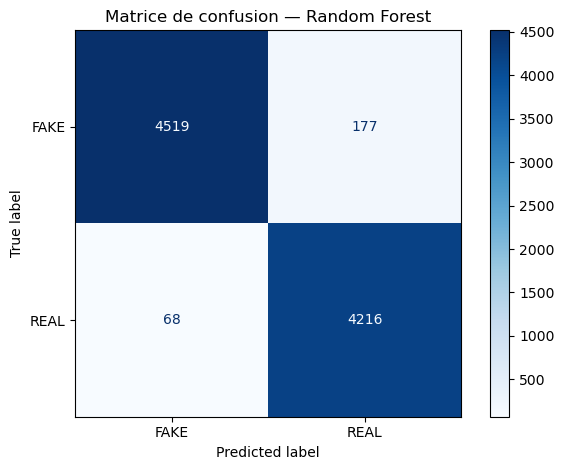


Training LinearSVC ...
Accuracy: 0.9755
              precision    recall  f1-score   support

        FAKE       0.98      0.97      0.98      4696
        REAL       0.97      0.98      0.97      4284

    accuracy                           0.98      8980
   macro avg       0.98      0.98      0.98      8980
weighted avg       0.98      0.98      0.98      8980



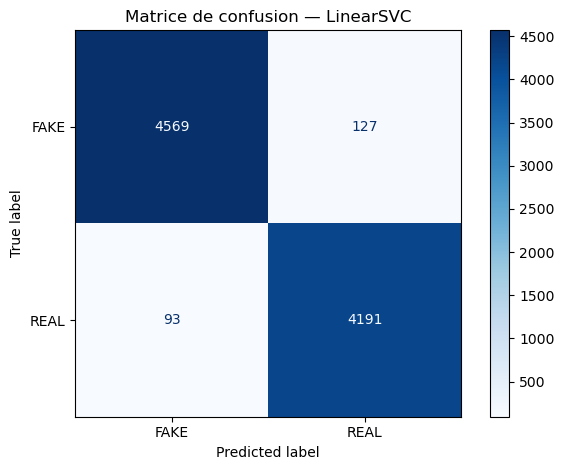

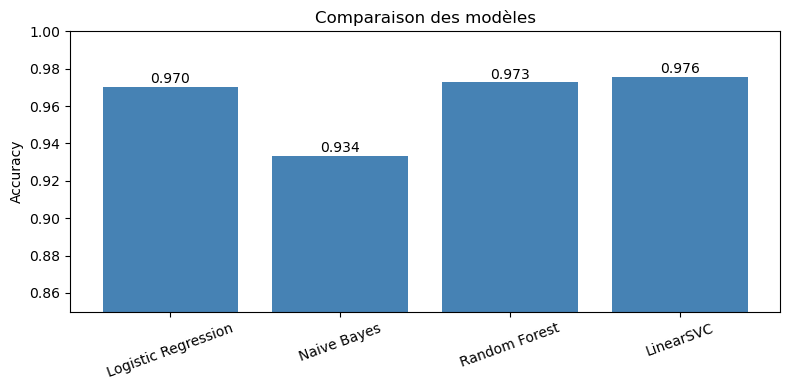


Meilleur modèle : LinearSVC (0.9755)


In [6]:
models = {
    'Logistic Regression' : LogisticRegression(max_iter=500),
    'Naive Bayes'         : MultinomialNB(),
    'Random Forest'       : RandomForestClassifier(n_estimators=100, max_depth=20, random_state=42),
    'LinearSVC'           : CalibratedClassifierCV(LinearSVC(max_iter=2000, random_state=42)),
}

results = {}

for name, model in models.items():
    print(f'\nTraining {name} ...')
    model.fit(X_train_sel, y_train)
    y_pred = model.predict(X_test_sel)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f'Accuracy: {acc:.4f}')
    print(classification_report(y_test, y_pred, target_names=['FAKE','REAL']))

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['FAKE','REAL'])
    disp.plot(cmap='Blues')
    plt.title(f'Matrice de confusion — {name}')
    plt.tight_layout()
    plt.show()

plt.figure(figsize=(8,4))
bars = plt.bar(results.keys(), results.values(), color='steelblue')
plt.ylim(0.85, 1.0)
plt.ylabel('Accuracy')
plt.title('Comparaison des modèles')
plt.xticks(rotation=20)
for bar, val in zip(bars, results.values()):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002,
             f'{val:.3f}', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

best = max(results, key=results.get)
print(f'\nMeilleur modèle : {best} ({results[best]:.4f})')

## 6. Évaluation — Prédiction sur de nouveaux articles

Je définis une fonction de prédiction qui prend un texte brut en entrée, applique tout le pipeline (nettoyage, vectorisation, sélection de features) et renvoie la classification avec le score de confiance. Je teste ensuite sur quelques exemples représentatifs.

In [8]:
best_model = models[best]

def predict_news(text):
    cleaned  = clean_text(text)
    vec      = vectorizer.transform([cleaned])
    selected = selector.transform(vec)
    pred     = best_model.predict(selected)[0]
    proba    = best_model.predict_proba(selected)[0]
    label    = 'REAL' if pred == 1 else 'FAKE'
    conf     = round(max(proba) * 100, 1)
    return label, conf

tests = [
    'The Federal Reserve raised interest rates by 0.25 percent on Wednesday.',
    'BREAKING: Hillary Clinton secretly arrested — Deep State exposed!',
    'Scientists discovered a new planet similar to Earth.',
]

print('=== Tests prédéfinis ===')
for news in tests:
    label, conf = predict_news(news)
    print(f'{label} ({conf}%) — "{news[:60]}..."')

print('\n=== Saisie manuelle ===')
print("Entrez votre article (ou 'quitter' pour arrêter)\n")

while True:
    user_input = input('Article : ').strip()
    if user_input.lower() in ('quitter', 'quit', 'q', ''):
        print('Fin.')
        break
    label, conf = predict_news(user_input)
    print(f'  Prédiction : {label}  |  Confiance : {conf}%\n')

=== Tests prédéfinis ===
REAL (98.4%) — "The Federal Reserve raised interest rates by 0.25 percent on..."
FAKE (99.5%) — "BREAKING: Hillary Clinton secretly arrested — Deep State exp..."
FAKE (95.9%) — "Scientists discovered a new planet similar to Earth...."

=== Saisie manuelle ===
Entrez votre article (ou 'quitter' pour arrêter)



Article :  The Federal Reserve raised interest rates by 0.25 percent on Wednesday.',    'The Federal Reserve raised interest rates by 0.25 percent on Wednesday.


  Prédiction : REAL  |  Confiance : 98.4%



Article :  quitter


Fin.


## 7. Conclusion

Ce projet m'a beaucoup appris sur le traitement du langage naturel appliqué à un vrai problème de classification.

**Ce que j'ai appris sur le NLP** : le preprocessing du texte est tout aussi important que le choix du modèle. Enlever le marqueur Reuters avant la vectorisation était une décision cruciale : sans ça, le modèle aurait appris un raccourci ("présence de Reuters = article réel") plutôt que le contenu sémantique des articles. Cela m'a sensibilisée à la notion de data leakage et à l'importance de comprendre ses données avant de modéliser.

**Sur l'ordre des opérations** : j'ai appris à être très rigoureuse sur l'ordre split → fit TF-IDF sur train → transform sur test. C'est une règle fondamentale que j'applique maintenant automatiquement sur tous mes projets.

**Sur les performances** : obtenir plus de 99% de précision sur ce dataset est techniquement atteignable avec des modèles simples comme Logistic Regression ou LinearSVC, ce qui montre que les features TF-IDF sont très discriminantes pour ce problème.

**Ce que je ferais en allant plus loin** : tester des embeddings contextuels (BERT, RoBERTa) pour capturer le sens des phrases plutôt que juste la fréquence des mots, et travailler sur des datasets plus récents pour voir si le modèle généralise bien.